# CfRadial1

In [1]:
import xarray as xr
from open_radar_data import DATASETS

import xradar as xd

## Download

Fetching CfRadial1 radar data file from [open-radar-data](https://github.com/openradar/open-radar-data) repository.

In [2]:
filename = DATASETS.fetch("cfrad.20080604_002217_000_SPOL_v36_SUR.nc")

## xr.open_dataset

Making use of the xarray `cfradial1` backend. We also need to provide the group.

In [3]:
ds = xr.open_dataset(filename, group="sweep_0", engine="cfradial1")
display(ds)

C:\Users\egoud\.venvs\wradlib\Lib\site-packages\xarray\backends\plugins.py:110: RuntimeWarning: Engine 'radolan' loading failed:
module 'wradlib.georef.raster' has no attribute 'read_gdal_values'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


<xarray.Dataset> Size: 4MB
Dimensions:                    (azimuth: 483, range: 996)
Coordinates:
  * azimuth                    (azimuth) float32 2kB 0.0 0.75 ... 358.5 359.2
    elevation                  (azimuth) float32 2kB ...
    time                       (azimuth) datetime64[ns] 4kB ...
  * range                      (range) float32 4kB 150.0 300.0 ... 1.494e+05
    latitude                   float64 8B ...
    longitude                  float64 8B ...
    altitude                   float64 8B ...
Data variables: (12/18)
    sweep_number               int32 4B ...
    sweep_mode                 <U20 80B ...
    prt_mode                   |S32 32B ...
    follow_mode                |S32 32B ...
    sweep_fixed_angle          float32 4B ...
    pulse_width                (azimuth) float32 2kB ...
    ...                         ...
    r_calib_index              (azimuth) int8 483B ...
    measured_transmit_power_h  (azimuth) float32 2kB ...
    measured_transmit_power_v  (azimuth) float32 2kB ...
    scan_rate                  (azimuth) float32 2kB ...
    DBZ                        (azimuth, range) float32 2MB ...
    VR                         (azimuth, range) float32 2MB ...

### Plot Time vs. Azimuth

We need to sort by time and specify the coordinate.

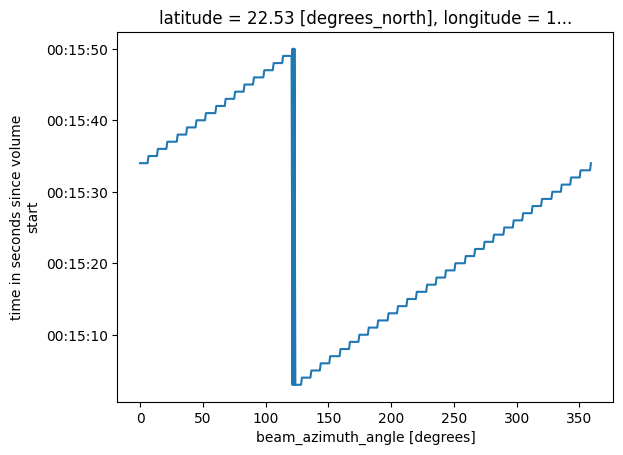

In [4]:
ds.azimuth.plot(y="time")

### Plot Range vs. Time

We need to sort by time and specify the coordinate.

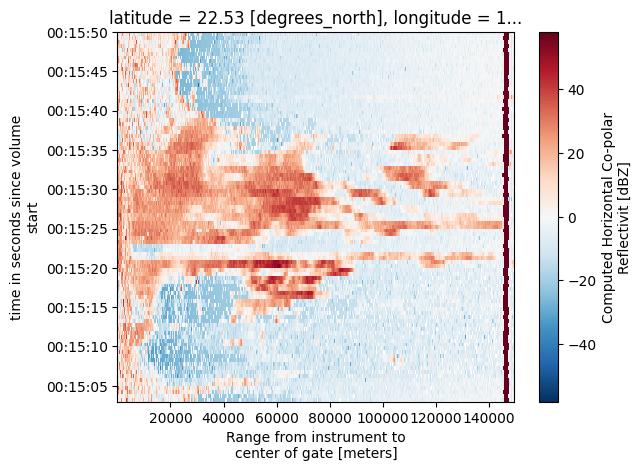

In [5]:
ds.DBZ.sortby("time").plot(y="time")

### Plot Range vs. Azimuth


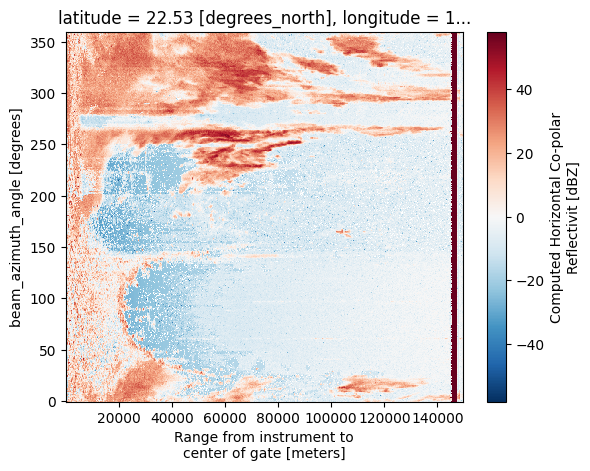

In [6]:
ds.DBZ.plot()

## backend_kwargs

The cfradial1 backend can be parameterized via kwargs. Please observe the possibilities below.

In [7]:
?xd.io.CfRadial1BackendEntrypoint

In [8]:
ds = xr.open_dataset(filename, group="sweep_0", engine="cfradial1", first_dim="time")
display(ds)

<xarray.Dataset> Size: 4MB
Dimensions:                    (time: 483, range: 996)
Coordinates:
    azimuth                    (time) float32 2kB ...
    elevation                  (time) float32 2kB ...
  * time                       (time) datetime64[ns] 4kB 2008-06-04T00:15:03 ...
  * range                      (range) float32 4kB 150.0 300.0 ... 1.494e+05
    latitude                   float64 8B ...
    longitude                  float64 8B ...
    altitude                   float64 8B ...
Data variables: (12/18)
    sweep_number               int32 4B ...
    sweep_mode                 <U20 80B ...
    prt_mode                   |S32 32B ...
    follow_mode                |S32 32B ...
    sweep_fixed_angle          float32 4B ...
    pulse_width                (time) float32 2kB ...
    ...                         ...
    r_calib_index              (time) int8 483B ...
    measured_transmit_power_h  (time) float32 2kB ...
    measured_transmit_power_v  (time) float32 2kB ...
    scan_rate                  (time) float32 2kB ...
    DBZ                        (time, range) float32 2MB ...
    VR                         (time, range) float32 2MB ...

In [9]:
ds = xr.open_dataset(
    filename, group="sweep_1", engine="cfradial1", backend_kwargs=dict(first_dim="time")
)
display(ds)

<xarray.Dataset> Size: 4MB
Dimensions:                    (time: 483, range: 996)
Coordinates:
    azimuth                    (time) float32 2kB ...
    elevation                  (time) float32 2kB ...
  * time                       (time) datetime64[ns] 4kB 2008-06-04T00:15:50 ...
  * range                      (range) float32 4kB 150.0 300.0 ... 1.494e+05
    latitude                   float64 8B ...
    longitude                  float64 8B ...
    altitude                   float64 8B ...
Data variables: (12/18)
    sweep_number               int32 4B ...
    sweep_mode                 <U20 80B ...
    prt_mode                   |S32 32B ...
    follow_mode                |S32 32B ...
    sweep_fixed_angle          float32 4B ...
    pulse_width                (time) float32 2kB ...
    ...                         ...
    r_calib_index              (time) int8 483B ...
    measured_transmit_power_h  (time) float32 2kB ...
    measured_transmit_power_v  (time) float32 2kB ...
    scan_rate                  (time) float32 2kB ...
    DBZ                        (time, range) float32 2MB ...
    VR                         (time, range) float32 2MB ...

## open_cfradial1_datatree

The same works analoguous with the datatree loader. But additionally we can provide a sweep number or list.

In [10]:
?xd.io.open_cfradial1_datatree

In [11]:
dtree = xd.io.open_cfradial1_datatree(
    filename,
    first_dim="time",
    optional=False,
)
display(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 9)
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int32 4B ...
│       time_coverage_start  |S32 32B ...
│       time_coverage_end    |S32 32B ...
│       latitude             float64 8B ...
│       longitude            float64 8B ...
│       altitude             float64 8B ...
│       sweep_group_name     (sweep) <U7 252B 'sweep_0' 'sweep_1' ... 'sweep_8'
│       sweep_fixed_angle    (sweep) float32 36B ...
│   Attributes:
│       Conventions:         CF/Radial instrument_parameters radar_parameters rad...
│       version:             1.2
│       title:               TIMREX
│       institution:         
│       references:          
│       source:              
│       history:             
│       comment:             
│       instrument_name:     SPOLRVP8
│       platform_is_mobile:  false
├── Group: /sweep_0
│       Dimensions:            (time: 483, range: 996)
│       Coordinates:
│           azimuth            (time) float32 2kB ...
│           elevation          (time) float32 2kB ...
│         * time               (time) datetime64[ns] 4kB 2008-06-04T00:15:03 ... 2008...
│         * range              (range) float32 4kB 150.0 300.0 ... 1.492e+05 1.494e+05
│           latitude           float64 8B ...
│           longitude          float64 8B ...
│           altitude           float64 8B ...
│       Data variables:
│           sweep_number       int32 4B ...
│           sweep_mode         <U20 80B 'azimuth_surveillance'
│           prt_mode           |S32 32B ...
│           follow_mode        |S32 32B ...
│           sweep_fixed_angle  float32 4B ...
│           DBZ                (time, range) float32 2MB ...
│           VR                 (time, range) float32 2MB ...
├── Group: /sweep_1
│       Dimensions:            (time: 483, range: 996)
│       Coordinates:
│           azimuth            (time) float32 2kB ...
│           elevation          (time) float32 2kB ...
│         * time               (time) datetime64[ns] 4kB 2008-06-04T00:15:50 ... 2008...
│         * range              (range) float32 4kB 150.0 300.0 ... 1.492e+05 1.494e+05
│           latitude           float64 8B ...
│           longitude          float64 8B ...
│           altitude           float64 8B ...
│       Data variables:
│           sweep_number       int32 4B ...
│           sweep_mode         <U20 80B 'azimuth_surveillance'
│           prt_mode           |S32 32B ...
│           follow_mode        |S32 32B ...
│           sweep_fixed_angle  float32 4B ...
│           DBZ                (time, range) float32 2MB ...
│           VR                 (time, range) float32 2MB ...
├── Group: /sweep_2
│       Dimensions:            (time: 482, range: 996)
│       Coordinates:
│           azimuth            (time) float32 2kB ...
│           elevation          (time) float32 2kB ...
│         * time               (time) datetime64[ns] 4kB 2008-06-04T00:16:40 ... 2008...
│         * range              (range) float32 4kB 150.0 300.0 ... 1.492e+05 1.494e+05
│           latitude           float64 8B ...
│           longitude          float64 8B ...
│           altitude           float64 8B ...
│       Data variables:
│           sweep_number       int32 4B ...
│           sweep_mode         <U20 80B 'azimuth_surveillance'
│           prt_mode           |S32 32B ...
│           follow_mode        |S32 32B ...
│           sweep_fixed_angle  float32 4B ...
│           DBZ                (time, range) float32 2MB ...
│           VR                 (time, range) float32 2MB ...
...
├── Group: /radar_parameters
│       Dimensions:                   ()
│       Data variables:
│           radar_beam_width_h        float32 4B ...
│           radar_beam_width_v        float32 4B ...
│           radar_antenna_gain_v      float32 4B ...
│           radar_antenna_gain_h      float32 4B ...
│           radar_receiver_bandwidth  float32 4B ...
├── Group

### Plot Sweep Range vs. Time

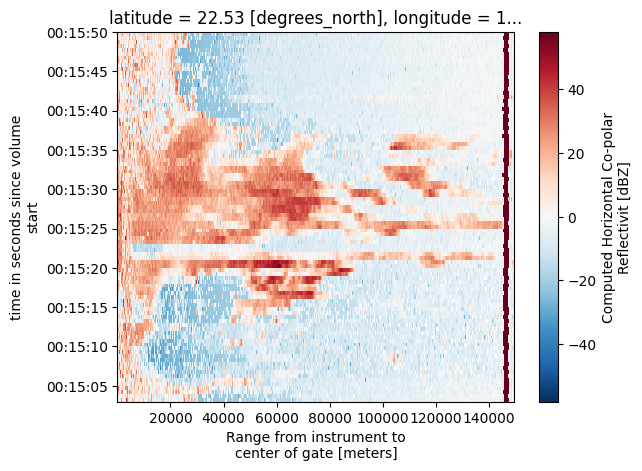

In [12]:
dtree["sweep_0"].ds.DBZ.plot()

### Plot Sweep Range vs. Azimuth

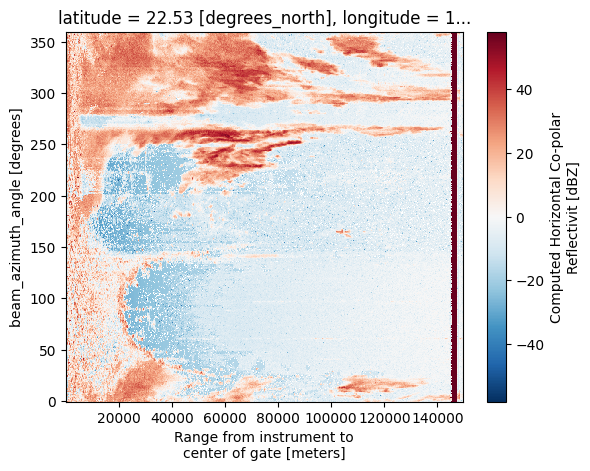

In [13]:
dtree["sweep_0"].ds.DBZ.sortby("azimuth").plot(y="azimuth")

In [14]:
dtree = xd.io.open_cfradial1_datatree(filename, sweep=[0, 1, 8])
display(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 9)
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int32 4B ...
│       platform_type        |S32 32B ...
│       primary_axis         |S32 32B ...
│       status_str           |S1 1B ...
│       instrument_type      |S32 32B ...
│       time_coverage_start  |S32 32B ...
│       time_coverage_end    |S32 32B ...
│       latitude             float64 8B ...
│       longitude            float64 8B ...
│       altitude             float64 8B ...
│       sweep_group_name     (sweep) <U7 252B 'sweep_0' 'sweep_1' ... 'sweep_8'
│       sweep_fixed_angle    (sweep) float32 36B ...
│   Attributes: (12/13)
│       Conventions:         CF/Radial instrument_parameters radar_parameters rad...
│       version:             1.2
│       title:               TIMREX
│       institution:         
│       references:          
│       source:              
│       ...                  ...
│       comment:             
│       instrument_name:     SPOLRVP8
│       site_name:           
│       scan_name:           
│       scan_id:             0
│       platform_is_mobile:  false
├── Group: /sweep_0
│       Dimensions:                    (azimuth: 483, range: 996)
│       Coordinates:
│         * azimuth                    (azimuth) float32 2kB 0.0 0.75 ... 358.5 359.2
│           elevation                  (azimuth) float32 2kB ...
│           time                       (azimuth) datetime64[ns] 4kB 2008-06-04T00:15:...
│         * range                      (range) float32 4kB 150.0 300.0 ... 1.494e+05
│           latitude                   float64 8B ...
│           longitude                  float64 8B ...
│           altitude                   float64 8B ...
│       Data variables: (12/18)
│           sweep_number               int32 4B ...
│           sweep_mode                 <U20 80B 'azimuth_surveillance'
│           prt_mode                   |S32 32B ...
│           follow_mode                |S32 32B ...
│           sweep_fixed_angle          float32 4B ...
│           pulse_width                (azimuth) float32 2kB ...
│           ...                         ...
│           r_calib_index              (azimuth) int8 483B ...
│           measured_transmit_power_h  (azimuth) float32 2kB ...
│           measured_transmit_power_v  (azimuth) float32 2kB ...
│           scan_rate                  (azimuth) float32 2kB ...
│           DBZ                        (azimuth, range) float32 2MB ...
│           VR                         (azimuth, range) float32 2MB ...
├── Group: /sweep_1
│       Dimensions:                    (azimuth: 483, range: 996)
│       Coordinates:
│         * azimuth                    (azimuth) float32 2kB 0.0 0.75 ... 358.5 359.2
│           elevation                  (azimuth) float32 2kB ...
│           time                       (azimuth) datetime64[ns] 4kB 2008-06-04T00:16:...
│         * range                      (range) float32 4kB 150.0 300.0 ... 1.494e+05
│           latitude                   float64 8B ...
│           longitude                  float64 8B ...
│           altitude                   float64 8B ...
│       Data variables: (12/18)
│           sweep_number               int32 4B ...
│           sweep_mode                 <U20 80B 'azimuth_surveillance'
│           prt_mode                   |S32 32B ...
│           follow_mode                |S32 32B ...
│           sweep_fixed_angle          float32 4B ...
│           pulse_width                (azimuth) float32 2kB ...
│           ...                         ...
│           r_calib_index              (azimuth) int8 483B ...
│           measured_transmit_power_h  (azimuth) float32 2kB ...
│           measured_transmit_power_v  (azimuth) float32 2kB ...
│           scan_rate                  (azimuth) float32 2kB ...
│           DBZ                        (azimuth, range) float32 2MB ...
│           VR                         (azimuth, range)

In [15]:
dtree = xd.io.open_cfradial1_datatree(filename, sweep=["sweep_0", "sweep_4", "sweep_8"])
display(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 9)
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int32 4B ...
│       platform_type        |S32 32B ...
│       primary_axis         |S32 32B ...
│       status_str           |S1 1B ...
│       instrument_type      |S32 32B ...
│       time_coverage_start  |S32 32B ...
│       time_coverage_end    |S32 32B ...
│       latitude             float64 8B ...
│       longitude            float64 8B ...
│       altitude             float64 8B ...
│       sweep_group_name     (sweep) <U7 252B 'sweep_0' 'sweep_1' ... 'sweep_8'
│       sweep_fixed_angle    (sweep) float32 36B ...
│   Attributes: (12/13)
│       Conventions:         CF/Radial instrument_parameters radar_parameters rad...
│       version:             1.2
│       title:               TIMREX
│       institution:         
│       references:          
│       source:              
│       ...                  ...
│       comment:             
│       instrument_name:     SPOLRVP8
│       site_name:           
│       scan_name:           
│       scan_id:             0
│       platform_is_mobile:  false
├── Group: /sweep_0
│       Dimensions:                    (azimuth: 483, range: 996)
│       Coordinates:
│         * azimuth                    (azimuth) float32 2kB 0.0 0.75 ... 358.5 359.2
│           elevation                  (azimuth) float32 2kB ...
│           time                       (azimuth) datetime64[ns] 4kB 2008-06-04T00:15:...
│         * range                      (range) float32 4kB 150.0 300.0 ... 1.494e+05
│           latitude                   float64 8B ...
│           longitude                  float64 8B ...
│           altitude                   float64 8B ...
│       Data variables: (12/18)
│           sweep_number               int32 4B ...
│           sweep_mode                 <U20 80B 'azimuth_surveillance'
│           prt_mode                   |S32 32B ...
│           follow_mode                |S32 32B ...
│           sweep_fixed_angle          float32 4B ...
│           pulse_width                (azimuth) float32 2kB ...
│           ...                         ...
│           r_calib_index              (azimuth) int8 483B ...
│           measured_transmit_power_h  (azimuth) float32 2kB ...
│           measured_transmit_power_v  (azimuth) float32 2kB ...
│           scan_rate                  (azimuth) float32 2kB ...
│           DBZ                        (azimuth, range) float32 2MB ...
│           VR                         (azimuth, range) float32 2MB ...
├── Group: /sweep_1
│       Dimensions:                    (azimuth: 481, range: 996)
│       Coordinates:
│         * azimuth                    (azimuth) float32 2kB 0.0 0.75 ... 358.5 359.2
│           elevation                  (azimuth) float32 2kB ...
│           time                       (azimuth) datetime64[ns] 4kB 2008-06-04T00:18:...
│         * range                      (range) float32 4kB 150.0 300.0 ... 1.494e+05
│           latitude                   float64 8B ...
│           longitude                  float64 8B ...
│           altitude                   float64 8B ...
│       Data variables: (12/18)
│           sweep_number               int32 4B ...
│           sweep_mode                 <U20 80B 'azimuth_surveillance'
│           prt_mode                   |S32 32B ...
│           follow_mode                |S32 32B ...
│           sweep_fixed_angle          float32 4B ...
│           pulse_width                (azimuth) float32 2kB ...
│           ...                         ...
│           r_calib_index              (azimuth) int8 481B ...
│           measured_transmit_power_h  (azimuth) float32 2kB ...
│           measured_transmit_power_v  (azimuth) float32 2kB ...
│           scan_rate                  (azimuth) float32 2kB ...
│           DBZ                        (azimuth, range) float32 2MB ...
│           VR                         (azimuth, range)